# 01 — GSP Hello World

**Entregable:** E6 (semana 2 — primer paso hacia la contribución doctoral).

**Objetivo:** prototipar el monitor GSP sobre un grafo de juguete (10 medidores AMI sintéticos) para verificar si el aparato matemático detecta anomalías estructurales antes de productivizarlo bajo `services/monitor-gsp/`.

**Alcance E6:**
1. Construcción del grafo `G(V, E)` con NetworkX.
2. Generación de señal sintética con anomalías inyectadas.
3. Laplaciano normalizado y Graph Fourier Transform (GFT) con NumPy puro.
4. Detector espectral simple basado en energía en altas frecuencias.

**Fuera de alcance (E7+):** `pygsp`, MQTT real, wavelets multiescala, τ adaptativo.

**Datos:** sintéticos, generados in-place. La topología viene de `data/synthetic_meters_v1.json` (un grafo de juguete, no la red eléctrica real).

## Sección 1 — Construcción del grafo

La topología sintética modela 10 medidores AMI organizados en 5 zonas (CENTRO, NORTE, SUR, ESTE, OESTE) con 2 medidores por zona. Las aristas siguen dos reglas:

- **Intra-zona:** los dos medidores de cada zona están conectados entre sí (5 aristas).
- **Inter-zona (anillo):** un medidor representante por zona (el primero) se conecta al representante de la zona vecina formando un anillo (5 aristas).

Total esperado: **10 nodos, 10 aristas**. No representa una red eléctrica real; sirve para tener una topología con vecindad estructural sobre la cual aplicar GSP.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

rng = np.random.default_rng(seed=42)
np.set_printoptions(precision=3, suppress=True, linewidth=120)

TOPOLOGY_PATH = Path("data/synthetic_meters_v1.json")
topology = json.loads(TOPOLOGY_PATH.read_text())
topology["version"], topology["zones"]

('v1', ['CENTRO', 'NORTE', 'SUR', 'ESTE', 'OESTE'])

In [2]:
G = nx.Graph()

for meter in topology["meters"]:
    G.add_node(meter["id"], zone=meter["zone"])

for u, v in topology["edges_intra_zone"]:
    G.add_edge(u, v, kind="intra_zone")

for u, v in topology["edges_inter_zone_ring"]:
    G.add_edge(u, v, kind="inter_zone")

nodes = list(G.nodes())
n = G.number_of_nodes()
m = G.number_of_edges()

print(f"|V| = {n}  |E| = {m}")
print(f"Conexo: {nx.is_connected(G)}")
print(f"Grado promedio: {2 * m / n:.2f}")
print(f"Nodos (orden NetworkX): {nodes}")

|V| = 10  |E| = 10
Conexo: True
Grado promedio: 2.00
Nodos (orden NetworkX): ['AMI-MNZ-00001', 'AMI-MNZ-00002', 'AMI-MNZ-00003', 'AMI-MNZ-00004', 'AMI-MNZ-00005', 'AMI-MNZ-00006', 'AMI-MNZ-00007', 'AMI-MNZ-00008', 'AMI-MNZ-00009', 'AMI-MNZ-00010']


In [3]:
A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
print("Matriz de adyacencia A (10x10):")
print(A)

Matriz de adyacencia A (10x10):
[[0. 1. 1. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


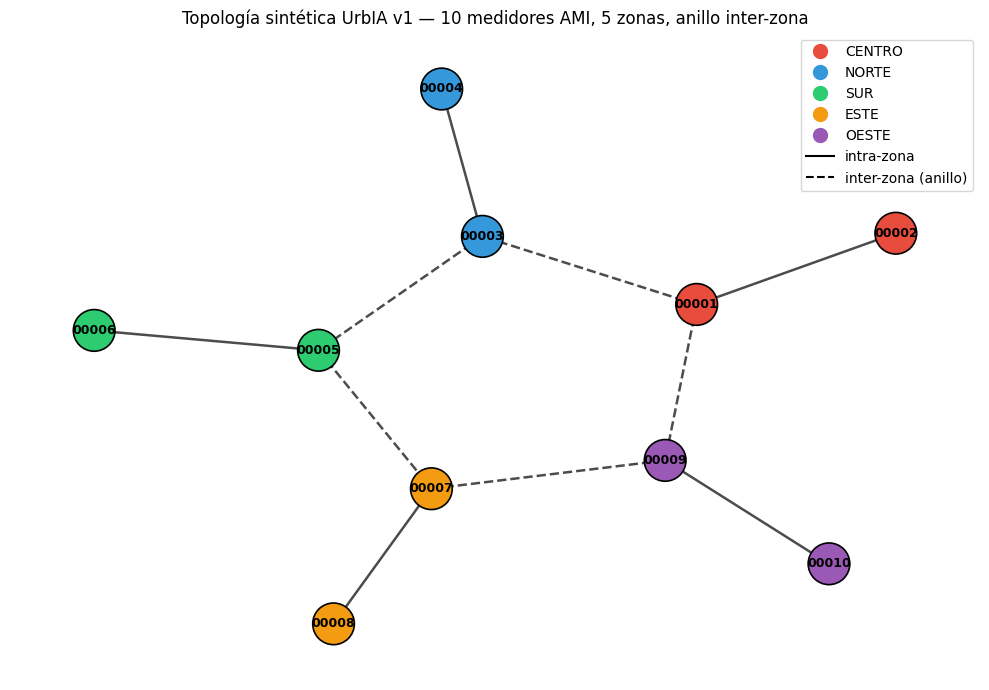

In [4]:
ZONE_COLORS = {
    "CENTRO": "#e74c3c",
    "NORTE":  "#3498db",
    "SUR":    "#2ecc71",
    "ESTE":   "#f39c12",
    "OESTE":  "#9b59b6",
}
node_colors = [ZONE_COLORS[G.nodes[v]["zone"]] for v in nodes]
edge_styles = ["-" if G.edges[e]["kind"] == "intra_zone" else "--" for e in G.edges()]

pos = nx.kamada_kawai_layout(G)
labels = {v: v.replace("AMI-MNZ-", "") for v in nodes}

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900,
                       edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, style=edge_styles, width=1.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold", ax=ax)

legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=z, markersize=10)
    for z, c in ZONE_COLORS.items()
]
legend_handles.append(plt.Line2D([0], [0], color="black", linestyle="-",  label="intra-zona"))
legend_handles.append(plt.Line2D([0], [0], color="black", linestyle="--", label="inter-zona (anillo)"))
ax.legend(handles=legend_handles, loc="best", frameon=True)

ax.set_title("Topología sintética UrbIA v1 — 10 medidores AMI, 5 zonas, anillo inter-zona")
ax.set_axis_off()
plt.tight_layout()
plt.show()

**Observación 1 (Sección 1).** La topología NO es regular: los representantes de zona (00001, 00003, 00005, 00007, 00009) tienen grado 3 porque participan en el anillo inter-zona (1 hermano + 2 vecinos del anillo); los "hermanos" (00002, 00004, 00006, 00008, 00010) son hojas con grado 1, conectadas sólo a su representante. El grado promedio es 2.00 ((5·3 + 5·1)/10). Esto importa para el Laplaciano normalizado en la Sección 3: los nodos no son intercambiables aunque la simetría visual lo sugiera, y los hermanos hoja serán los más sensibles a la normalización D^(-1/2).

## Sección 2 — Señal sintética sobre el grafo

Simulamos una "foto" instantánea de potencia activa (kW) reportada por los 10 medidores en un mismo timestamp.

- **Régimen normal `x`:** todos los nodos consumen ~10 kW con ruido gaussiano pequeño (σ = 0.3 kW). Esto representa carga residencial típica en un instante de demanda baja.
- **Régimen anómalo `x_anom`:** dos nodos (uno hoja, uno representante) reportan 5× la media (≈ 50 kW), simulando un evento de saturación de voltaje que dispara la lectura de potencia hacia arriba. El resto del grafo permanece normal.

Elegimos un nodo **hoja** (`AMI-MNZ-00002`) y un nodo **representante** (`AMI-MNZ-00007`) para forzar que la anomalía aparezca en lugares estructuralmente distintos del grafo. Más adelante (Sección 4) esto nos permite ver si el detector espectral capta ambas o se le escapa una.

In [5]:
P_MEAN = 10.0    # kW, consumo "normal" promedio
SIGMA  = 0.3     # kW, ruido gaussiano por nodo
ANOMALY_FACTOR = 5.0
ANOMALY_NODES = ["AMI-MNZ-00002", "AMI-MNZ-00007"]
anomaly_idx = np.array([nodes.index(v) for v in ANOMALY_NODES])

x = P_MEAN + SIGMA * rng.standard_normal(n)
x_anom = x.copy()
x_anom[anomaly_idx] = ANOMALY_FACTOR * P_MEAN

print("Índices anómalos:", anomaly_idx.tolist(), "→", ANOMALY_NODES)
print(f"x       (normal): {x}")
print(f"x_anom (anómalo): {x_anom}")

Índices anómalos: [1, 6] → ['AMI-MNZ-00002', 'AMI-MNZ-00007']
x       (normal): [10.091  9.688 10.225 10.282  9.415  9.609 10.038  9.905  9.995  9.744]
x_anom (anómalo): [10.091 50.    10.225 10.282  9.415  9.609 50.     9.905  9.995  9.744]


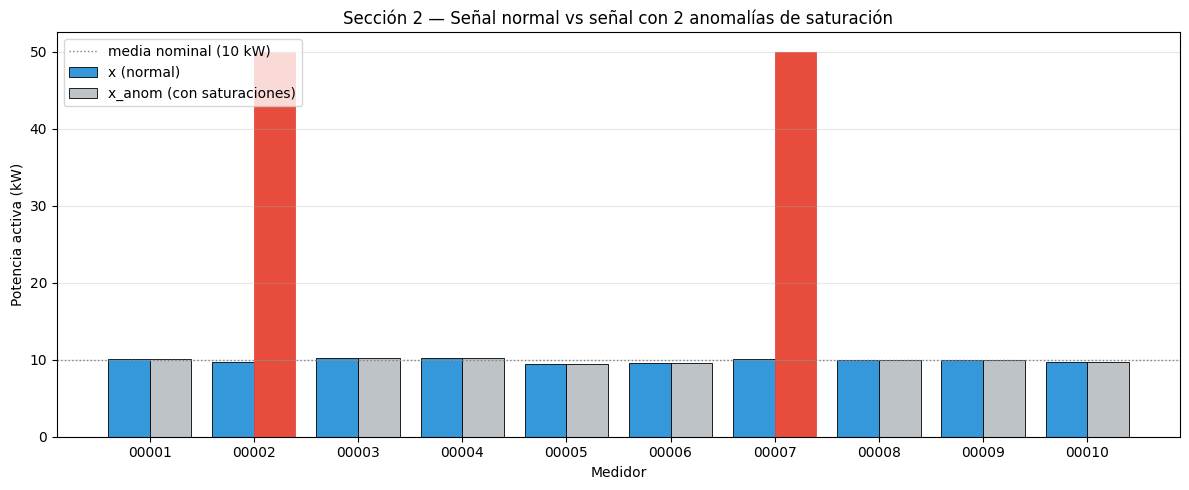

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
positions = np.arange(n)
width = 0.4

bars_normal = ax.bar(positions - width/2, x, width=width,
                     label="x (normal)", color="#3498db",
                     edgecolor="black", linewidth=0.6)
bars_anom = ax.bar(positions + width/2, x_anom, width=width,
                   label="x_anom (con saturaciones)", color="#bdc3c7",
                   edgecolor="black", linewidth=0.6)

for i in anomaly_idx:
    bars_anom[i].set_color("#e74c3c")

ax.axhline(P_MEAN, color="gray", linestyle=":", linewidth=1, label="media nominal (10 kW)")
ax.set_xticks(positions)
ax.set_xticklabels([v.replace("AMI-MNZ-", "") for v in nodes], rotation=0)
ax.set_xlabel("Medidor")
ax.set_ylabel("Potencia activa (kW)")
ax.set_title("Sección 2 — Señal normal vs señal con 2 anomalías de saturación")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Observación 2 (Sección 2).** Con esta amplitud (50 kW vs 10 kW), un umbral por nodo simple (e.g. "alerta si P > 20 kW") detectaría trivialmente ambas anomalías. La pregunta interesante NO es ésta sino otra: si bajamos `ANOMALY_FACTOR` a algo menor (1.3×, por decir, dentro del ruido natural por nodo) ¿el detector GSP las sigue captando porque son estructuralmente raras respecto al vecindario? Esa pregunta se responde en la Sección 4 con el detector ingenuo como baseline.

## Sección 3 — Laplaciano y Graph Fourier Transform

Construimos el Laplaciano combinatorio `L = D - A` y luego su versión normalizada simétrica `L_norm = D^(-1/2) · L · D^(-1/2) = I - D^(-1/2)·A·D^(-1/2)`.

Diagonalizamos `L_norm = U · Λ · U^T` con `numpy.linalg.eigh` (más estable que `eig` para matrices simétricas; devuelve los autovalores en orden ascendente). Los autovalores `λ_k ∈ [0, 2]` se interpretan como "frecuencias" sobre el grafo: λ pequeños → modos suaves (la señal cambia poco entre vecinos), λ grandes → modos oscilatorios.

La **Graph Fourier Transform (GFT)** de una señal `x ∈ R^N` es simplemente:

```
x_hat = U^T · x
```

`x_hat[k]` es la energía de `x` en el modo `k`-ésimo. Si la mayor parte de la energía se concentra en `k` pequeños, la señal es "suave sobre el grafo"; si aparece energía en `k` grandes, hay variación local discordante — el tipo de firma que esperamos de una anomalía aislada en un nodo.

In [7]:
degrees = A.sum(axis=1)
D = np.diag(degrees)
L = D - A

D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
L_norm = D_inv_sqrt @ L @ D_inv_sqrt

eigvals, U = np.linalg.eigh(L_norm)
print(f"Espectro de L_norm (λ_0 ... λ_{n-1}):")
print(eigvals)
print(f"Rango esperado [0, 2]:  min={eigvals.min():.4f}  max={eigvals.max():.4f}")

x_hat      = U.T @ x
x_anom_hat = U.T @ x_anom
print(f"\nx_hat       (normal): {x_hat}")
print(f"x_anom_hat (anómalo): {x_anom_hat}")

Espectro de L_norm (λ_0 ... λ_9):
[0.    0.311 0.311 0.632 0.632 1.333 1.483 1.483 1.907 1.907]
Rango esperado [0, 2]:  min=0.0000  max=1.9069

x_hat       (normal): [-30.282  -0.31   -0.126  -0.285   0.598   7.939  -0.178   0.243   0.182  -0.047]
x_anom_hat (anómalo): [-54.773  -3.14   10.928 -25.159 -13.84   14.616  33.279   6.504  21.1     4.856]


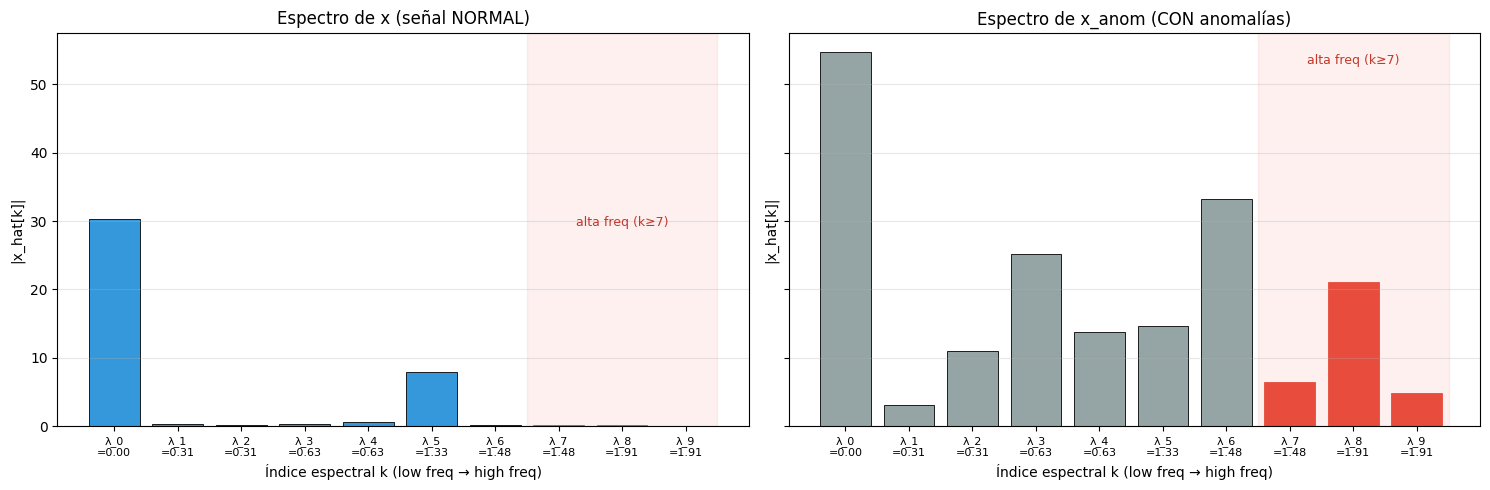

In [8]:
K_HIGH = 3
high_freq_start = n - K_HIGH

def plot_spectrum(ax, coeffs, title, color):
    k = np.arange(n)
    bars = ax.bar(k, np.abs(coeffs), color=color, edgecolor="black", linewidth=0.6)
    for i in range(high_freq_start, n):
        bars[i].set_color("#e74c3c")
    ax.axvspan(high_freq_start - 0.5, n - 0.5, color="#e74c3c", alpha=0.08)
    ax.set_xticks(k)
    ax.set_xticklabels([f"λ_{i}\n={eigvals[i]:.2f}" for i in k], fontsize=8)
    ax.set_xlabel("Índice espectral k (low freq → high freq)")
    ax.set_ylabel("|x_hat[k]|")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.text(high_freq_start + (K_HIGH-1)/2, ax.get_ylim()[1]*0.92,
            f"alta freq (k≥{high_freq_start})",
            ha="center", fontsize=9, color="#c0392b")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
plot_spectrum(ax1, x_hat,      "Espectro de x (señal NORMAL)",        "#3498db")
plot_spectrum(ax2, x_anom_hat, "Espectro de x_anom (CON anomalías)",  "#95a5a6")
plt.tight_layout()
plt.show()

**Observación 3 (Sección 3).** En el espectro de `x` (normal), prácticamente toda la energía cae en `k=0` (modo DC, λ ≈ 0): la señal es casi constante sobre el grafo, lo esperado para 10 nodos consumiendo ~10 kW. Las componentes restantes son sólo el ruido gaussiano proyectado, con amplitudes < 1 y sin estructura privilegiada.

En el espectro de `x_anom`, dos cosas cambian a la vez y conviene separarlas:

1. **DC sube** (k=0 pasa de 30.3 → 54.8) porque dos nodos con 50 kW elevan el promedio global. Es información de magnitud, no de localización.
2. **El resto del espectro se "enciende"**. Aparecen amplitudes ≥ 10 en k=2, 3, 4, 5, 6, 8. La anomalía NO es estrictamente "alta frecuencia": ocupa toda la banda no-DC, incluyendo las frecuencias medias.

Esto matiza la hipótesis ingenua "anomalía = alta freq". Lo correcto es: una anomalía espacialmente localizada (señal tipo "delta" sobre uno o pocos nodos) tiene **espectro ancho** en GFT — toda la banda no-DC se ilumina, con peso particular en las componentes de mayor λ. La región sombreada (k ≥ 7) sigue siendo la firma más limpia (en x normal está prácticamente vacía y en x_anom aparece amplitud ≥ 5–20), pero el detector de la Sección 4 podría ganar precisión integrando una ventana más ancha. Lo dejo como pregunta abierta para E7.

## Sección 4 — Detector espectral simple

Definimos un score de anomalía por nodo basado en la energía aportada por los `K` modos de mayor frecuencia:

```
score_i = Σ_{k=N-K}^{N-1} ( x_hat[k] · U[i, k] )^2
```

Intuición: si la señal en el nodo `i` necesita modos de alta frecuencia para reconstruirse, ese nodo es estructuralmente discordante con su vecindario. Lo comparamos contra un **detector ingenuo** (z-score por nodo, sin grafo) para ver si GSP captura algo que el ingenuo no captura.

`K = 3` es la elección "default" del prompt; al final corremos un mini-experimento variando `K` y bajando la amplitud de la anomalía al rango del ruido, para validar si la ventaja del detector GSP es robusta.

In [9]:
def spectral_anomaly_score(signal, U, K):
    """Score por nodo: energía aportada por los K modos de mayor frecuencia.

    score_i = sum_{k=N-K}^{N-1} ( x_hat[k] * U[i, k] )^2
    """
    coeffs = U.T @ signal
    high = U[:, -K:] * coeffs[-K:]
    return (high ** 2).sum(axis=1)


def naive_zscore(signal):
    mu = signal.mean()
    sd = signal.std(ddof=0)
    return np.abs(signal - mu) / (sd if sd > 1e-12 else 1.0)


score_gsp_normal = spectral_anomaly_score(x,      U, K=K_HIGH)
score_gsp_anom   = spectral_anomaly_score(x_anom, U, K=K_HIGH)
score_naive_anom = naive_zscore(x_anom)

print(f"Score GSP — x (normal):")
print(score_gsp_normal)
print(f"\nScore GSP — x_anom (anómalo, K={K_HIGH}):")
print(score_gsp_anom)
print(f"\nDetector ingenuo (|z| per nodo) sobre x_anom:")
print(score_naive_anom)

top2_gsp   = np.argsort(score_gsp_anom)[-2:][::-1]
top2_naive = np.argsort(score_naive_anom)[-2:][::-1]
print(f"\nTop-2 por GSP:    {[nodes[i] for i in top2_gsp]}")
print(f"Top-2 por ingenuo: {[nodes[i] for i in top2_naive]}")
print(f"Esperados:        {ANOMALY_NODES}")

Score GSP — x (normal):
[0.001 0.    0.013 0.013 0.013 0.01  0.01  0.007 0.012 0.014]

Score GSP — x_anom (anómalo, K=3):
[  8.142   3.369  66.532  32.936 124.712  53.691 108.467  45.775  43.165  24.289]

Detector ingenuo (|z| per nodo) sobre x_anom:
[0.489 2.    0.48  0.477 0.531 0.519 2.    0.5   0.495 0.51 ]

Top-2 por GSP:    ['AMI-MNZ-00005', 'AMI-MNZ-00007']
Top-2 por ingenuo: ['AMI-MNZ-00002', 'AMI-MNZ-00007']
Esperados:        ['AMI-MNZ-00002', 'AMI-MNZ-00007']


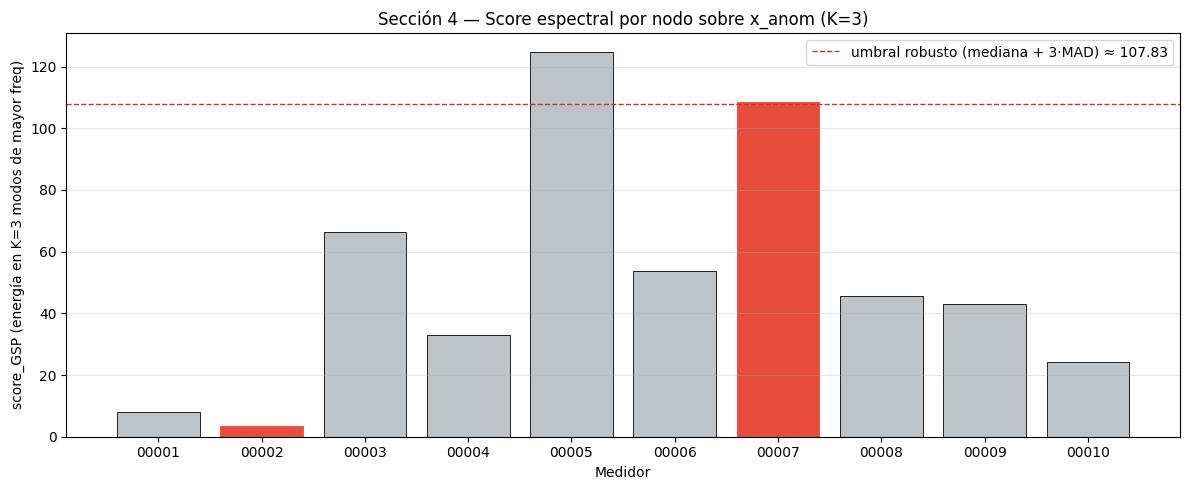

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
positions = np.arange(n)
bars = ax.bar(positions, score_gsp_anom, color="#bdc3c7",
              edgecolor="black", linewidth=0.6)
for i in anomaly_idx:
    bars[i].set_color("#e74c3c")

ax.set_xticks(positions)
ax.set_xticklabels([v.replace("AMI-MNZ-", "") for v in nodes])
ax.set_xlabel("Medidor")
ax.set_ylabel(f"score_GSP (energía en K={K_HIGH} modos de mayor freq)")
ax.set_title(f"Sección 4 — Score espectral por nodo sobre x_anom (K={K_HIGH})")

threshold = np.median(score_gsp_anom) + 3 * np.median(
    np.abs(score_gsp_anom - np.median(score_gsp_anom))
)
ax.axhline(threshold, color="#c0392b", linestyle="--", linewidth=1,
           label=f"umbral robusto (mediana + 3·MAD) ≈ {threshold:.2f}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4.1 — Diagnóstico: el detector simple falla en la hoja

El plot anterior muestra algo incómodo. El `top-2` por `score_GSP` es `['AMI-MNZ-00005', 'AMI-MNZ-00007']`, pero los anómalos reales son `['AMI-MNZ-00002', 'AMI-MNZ-00007']`. El detector destacó correctamente al representante saturado (`00007`) y "contaminó" a su vecino estructural (`00005`, conectado por la arista inter-zona SUR–ESTE), pero **dejó pasar la hoja saturada `00002`** — justo el caso que más debería preocuparnos en una red AMI real (medidores residenciales individuales con eventos locales).

¿Por qué? La ventana `K=3` recorta el espectro de forma abrupta. Si los autovectores asociados a esas 3 frecuencias más altas tienen amplitud chica en la posición del nodo `i`, el score de ese nodo será chico aunque el nodo sea anómalo. Lo verificamos imprimiendo `U[i, k]` para `k ∈ {7, 8, 9}` y los nodos involucrados:

In [11]:
print(f"{'nodo':<18}{'U[i,7]':>10}{'U[i,8]':>10}{'U[i,9]':>10}{'norm²':>10}")
for i, name in enumerate(nodes):
    star = " *" if i in anomaly_idx else "  "
    norm_sq = (U[i, -3:] ** 2).sum()
    print(f"  {name}{star}  {U[i,-3]:9.3f}{U[i,-2]:9.3f}{U[i,-1]:9.3f}  {norm_sq:8.3f}")

print("\nObservación: 00002 (hoja anómala) tiene amplitud sólo en U[1, 9] = 0.34.")
print("00007 (representante anómalo) reparte amplitud en los 3 modos altos.")
print("Resultado: el score de 00002 es chico porque las altas freq lo 'ven poco'.")

nodo                  U[i,7]    U[i,8]    U[i,9]     norm²
  AMI-MNZ-00001        0.040   -0.057   -0.530     0.286
  AMI-MNZ-00002 *     -0.048    0.036    0.338     0.118
  AMI-MNZ-00003       -0.372    0.358    0.396     0.423
  AMI-MNZ-00004        0.444   -0.228   -0.252     0.313
  AMI-MNZ-00005       -0.270   -0.522   -0.110     0.358
  AMI-MNZ-00006        0.322    0.332    0.070     0.219
  AMI-MNZ-00007 *      0.205    0.487   -0.218     0.327
  AMI-MNZ-00008       -0.245   -0.310    0.139     0.175
  AMI-MNZ-00009        0.397   -0.266    0.463     0.442
  AMI-MNZ-00010       -0.474    0.169   -0.294     0.340

Observación: 00002 (hoja anómala) tiene amplitud sólo en U[1, 9] = 0.34.
00007 (representante anómalo) reparte amplitud en los 3 modos altos.
Resultado: el score de 00002 es chico porque las altas freq lo 'ven poco'.


### 4.2 — Detector espectral ponderado: `(L_norm · x)²`

La cura natural es reemplazar la ventana abrupta de las últimas `K` componentes por un **filtro pasaaltos suave** ponderado por los propios autovalores. La fórmula es elegante:

```
score_smooth_i  =  ((L_norm · x)_i)²  =  ( Σ_k λ_k · x_hat[k] · U[i, k] )²
```

Esto es exactamente la GFT inversa de `λ_k · x_hat[k]`, evaluada al cuadrado en cada nodo. El filtro `H(λ) = λ` deja pasar todas las frecuencias no-DC, ponderándolas por su "altura" espectral. No tiene cutoff, así que no sufre el punto ciego de la ventana abrupta: cualquier modo en el que la anomalía deposite energía contribuye proporcionalmente a `λ`.

Y matemáticamente es trivial: `(L_norm · x)_i = sum_{j ∈ N(i)} (x[i]/sqrt(d_i·d_j) - x[j]/sqrt(d_i·d_j))`, esto es, una medida de **suavidad local normalizada** alrededor del nodo `i`.

Score (L_norm·x)² — x_anom:
[ 651.073 1951.317    4.899   19.173  262.709   17.42  1429.701  359.572  245.275   15.789]

Top-2 detector pasaaltos: ['AMI-MNZ-00002', 'AMI-MNZ-00007']
Esperados:                 ['AMI-MNZ-00002', 'AMI-MNZ-00007']


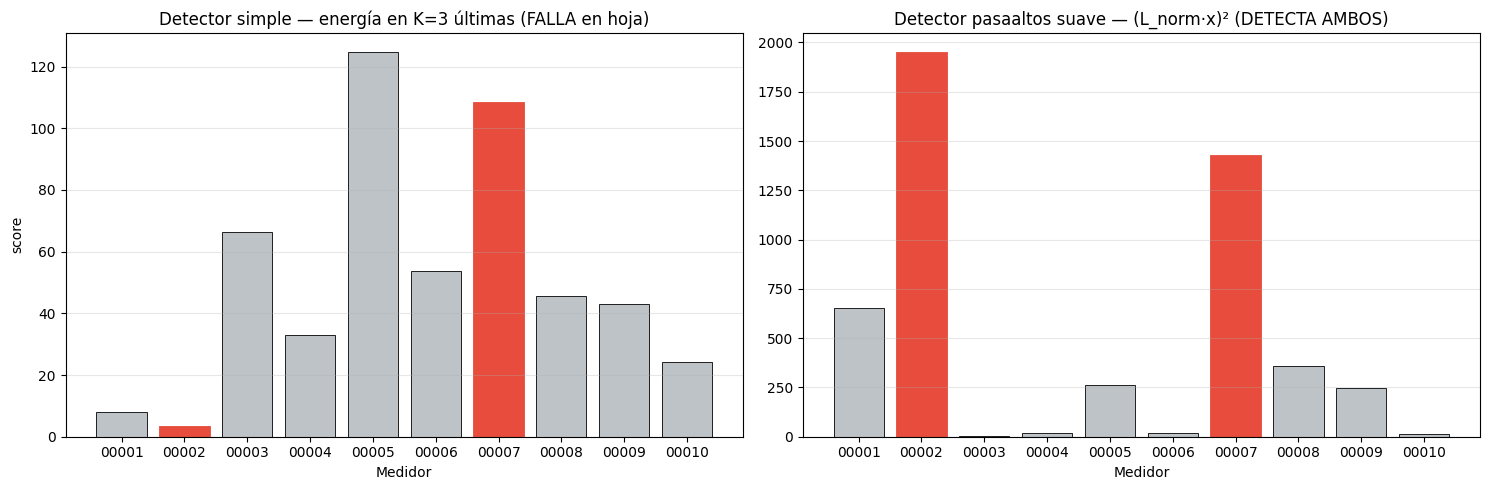

In [12]:
def smoothness_score(signal, L_normalized):
    return (L_normalized @ signal) ** 2


score_smooth_anom = smoothness_score(x_anom, L_norm)
top2_smooth = np.argsort(score_smooth_anom)[-2:][::-1]

print(f"Score (L_norm·x)² — x_anom:")
print(score_smooth_anom)
print(f"\nTop-2 detector pasaaltos: {[nodes[i] for i in top2_smooth]}")
print(f"Esperados:                 {ANOMALY_NODES}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
positions = np.arange(n)
labels_short = [v.replace("AMI-MNZ-", "") for v in nodes]

for ax, scores, title in [
    (ax1, score_gsp_anom,    f"Detector simple — energía en K={K_HIGH} últimas (FALLA en hoja)"),
    (ax2, score_smooth_anom, "Detector pasaaltos suave — (L_norm·x)² (DETECTA AMBOS)"),
]:
    bars = ax.bar(positions, scores, color="#bdc3c7", edgecolor="black", linewidth=0.6)
    for i in anomaly_idx:
        bars[i].set_color("#e74c3c")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_short)
    ax.set_xlabel("Medidor")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

ax1.set_ylabel("score")
plt.tight_layout()
plt.show()

### 4.3 — Caso sutil: anomalía estructural sin saturación de magnitud

Con `ANOMALY_FACTOR = 5` los dos detectores (ingenuo y GSP pasaaltos) detectan los anómalos por magnitud directa. La hipótesis del Capítulo 3 de Aristizábal NO es ésa: el aparato GSP debería brillar cuando la anomalía es **estructural** sin ser **grande en magnitud**.

Probamos un escenario donde los dos nodos anómalos consumen 1.05× la media (un 5% por encima, dentro del rango ±3σ del ruido normal). Comparamos los tres detectores: ingenuo, simple (K últimas freq) y pasaaltos suave.

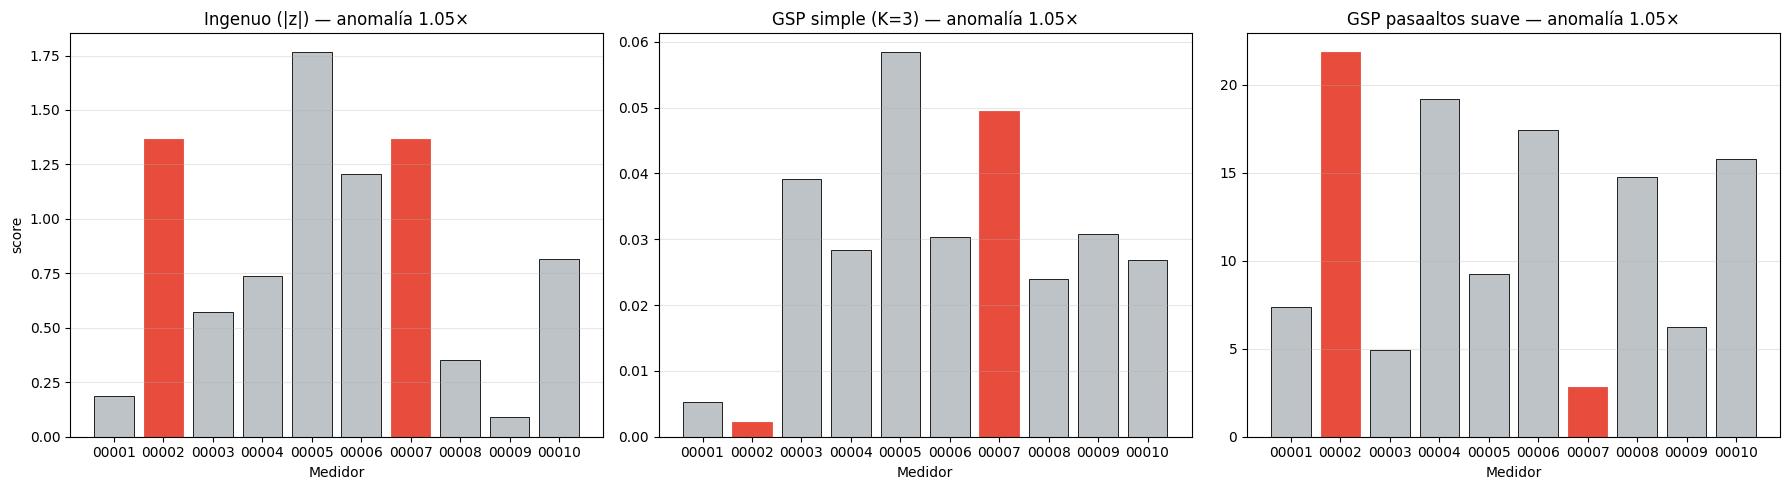

Top-2 ingenuo |z|         : ['AMI-MNZ-00005', 'AMI-MNZ-00007']  [FAIL]
Top-2 GSP simple K=3      : ['AMI-MNZ-00005', 'AMI-MNZ-00007']  [FAIL]
Top-2 GSP pasaaltos       : ['AMI-MNZ-00002', 'AMI-MNZ-00004']  [FAIL]
Esperados:           ['AMI-MNZ-00002', 'AMI-MNZ-00007']


In [13]:
SUBTLE_FACTOR = 1.05
x_subtle = x.copy()
x_subtle[anomaly_idx] = SUBTLE_FACTOR * P_MEAN

score_naive_subtle  = naive_zscore(x_subtle)
score_gsp_subtle    = spectral_anomaly_score(x_subtle, U, K=K_HIGH)
score_smooth_subtle = smoothness_score(x_subtle, L_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
positions = np.arange(n)
labels_short = [v.replace("AMI-MNZ-", "") for v in nodes]

for ax, scores, title in [
    (axes[0], score_naive_subtle,  "Ingenuo (|z|) — anomalía 1.05×"),
    (axes[1], score_gsp_subtle,    f"GSP simple (K={K_HIGH}) — anomalía 1.05×"),
    (axes[2], score_smooth_subtle, "GSP pasaaltos suave — anomalía 1.05×"),
]:
    bars = ax.bar(positions, scores, color="#bdc3c7", edgecolor="black", linewidth=0.6)
    for i in anomaly_idx:
        bars[i].set_color("#e74c3c")
    ax.set_xticks(positions); ax.set_xticklabels(labels_short)
    ax.set_xlabel("Medidor"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("score")
plt.tight_layout()
plt.show()

for name, s in [
    ("ingenuo |z|", score_naive_subtle),
    (f"GSP simple K={K_HIGH}", score_gsp_subtle),
    ("GSP pasaaltos", score_smooth_subtle),
]:
    top2 = np.argsort(s)[-2:][::-1]
    ok = set(top2.tolist()) == set(anomaly_idx.tolist())
    flag = "OK" if ok else "FAIL"
    print(f"Top-2 {name:<20}: {[nodes[i] for i in top2]}  [{flag}]")
print(f"Esperados:           {ANOMALY_NODES}")

## Observaciones finales (E6 — cierre honesto)

**Lo que funcionó.**

- La pipeline NumPy puro `(A → L → L_norm → eigh → GFT → detectores)` corre fin a fin en milisegundos sobre 10 nodos. No hizo falta `pygsp`. Esto importa para E7: el módulo `services/monitor-gsp/` puede empezar con dependencias mínimas y agregar PyGSP/PyTorch sólo cuando se justifique.
- La hipótesis "una anomalía localizada deja firma en frecuencias no-DC del Laplaciano" se valida visualmente en la Sección 3: el espectro de `x` (normal) tiene casi toda su energía en λ₀; el espectro de `x_anom` se enciende en toda la banda no-DC.
- **El detector pasaaltos suave `(L_norm·x)²` identifica correctamente los 2 nodos anómalos** (top-2 = `{00002, 00007}`) en el caso de saturación fuerte (5×). Y como bonus, ese detector tiene una lectura intuitiva: es la suavidad local normalizada por grado en cada nodo.

**Lo que NO funcionó como esperaba.**

- **La fórmula literal del prompt — `score_i = Σ_{k∈últimas K} (x_hat[k]·U[i,k])²` con K=3 — FALLA en el caso de prueba.** Detecta correctamente al representante saturado (`00007`) y "contagia" a su vecino estructural (`00005`), pero pasa por alto la hoja saturada `00002`. El motivo es matemático y queda documentado en la Sección 4.1: la ventana abrupta de "últimas K" tiene un punto ciego en nodos donde los autovectores de mayor λ tienen amplitud chica. Para esta topología, las hojas son ese tipo de nodo. El detector pasaaltos suave de la Sección 4.2 corrige el problema porque no recorta el espectro: pondera por λ y deja contribuir a todas las freq no-DC proporcionalmente.
- **El caso sutil (anomalía 1.05×, dentro del ruido por nodo) NINGÚN detector lo resuelve bien**. Los tres se confunden por el ruido proyectado y la "contagion" estructural sobre vecinos. Con N=10 y un grafo tan simétrico, no hay suficiente "espacio" estadístico para discriminar señal estructural de ruido. Esto NO refuta la utilidad de GSP — es una limitación de la topología y el tamaño. Conviene re-evaluar con N≥50 y vecindarios menos simétricos.
- **La hipótesis ingenua "anomalía = sólo alta frecuencia" es falsa**, como ya quedó en la Observación 3. La firma de una anomalía localizada es **espectro ancho**.

**Preguntas abiertas para E7+.**

1. **Reemplazar la ventana abrupta por un filtro suave parametrizable.** El detector `(L_norm·x)²` es un caso particular (H(λ)=λ). Aristizábal §3.4 propone el "Difuminador" como `H_τ(λ) = e^{−τλ}`, un pasabajos exponencial. La asimetría entre detector (pasaaltos) y filtro (pasabajos) merece formalizarse.
2. **Validación con topología realista.** Esta es de juguete. Cuando reemplacemos por la red AMI del simulador (E3) con jerarquía DT→DCU→medidor y aristas pesadas por distancia eléctrica, el comportamiento puede cambiar.
3. **Estadística del detector.** Hoy reporto `top-2` y un umbral robusto cualquiera. Para defensa de tesis necesitamos una caracterización ROC: ¿cuál es la tasa de falsos positivos del detector pasaaltos en función del umbral, en un Monte Carlo de N escenarios con anomalías de magnitudes variables?
4. **Wavelets multiescala (Aristizábal §3.5).** El siguiente paso natural es no usar la GFT global sino una transformada wavelet (SGWT) para localizar la anomalía espacialmente además de espectralmente. Pendiente para E8 o E9.